In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Load resolved dataset
df = pd.read_csv("../data/fda_resolved.csv")

# Split groups
group_a = df[df['classification'] == 'Class I']['resolution_days']
group_b = df[df['classification'] == 'Class II']['resolution_days']

print(f"Data Loaded")
print(f"Class I  : {len(group_a):,} records")
print(f"Class II : {len(group_b):,} records")

Data Loaded
Class I  : 1,464 records
Class II : 11,778 records


In [11]:
# Number of Monte Carlo samples
n_samples = 100000

# Model Class I resolution days as a normal distribution
# Sample from posterior using observed mean and std
posterior_a = np.random.normal(
    loc=group_a.mean(),
    scale=group_a.std() / np.sqrt(len(group_a)),
    size=n_samples
)

# Model Class II resolution days
posterior_b = np.random.normal(
    loc=group_b.mean(),
    scale=group_b.std() / np.sqrt(len(group_b)),
    size=n_samples
)

# Calculate probability that Class I takes longer than Class II
prob_a_slower = (posterior_a > posterior_b).mean()
print("\n        BAYESIAN ANALYSIS RESULTS")
print(f"\nP(Class I slower than Class II) : {prob_a_slower:.6f}")
print(f"In percentage                   : {prob_a_slower*100:.4f}%")


        BAYESIAN ANALYSIS RESULTS

P(Class I slower than Class II) : 1.000000
In percentage                   : 100.0000%


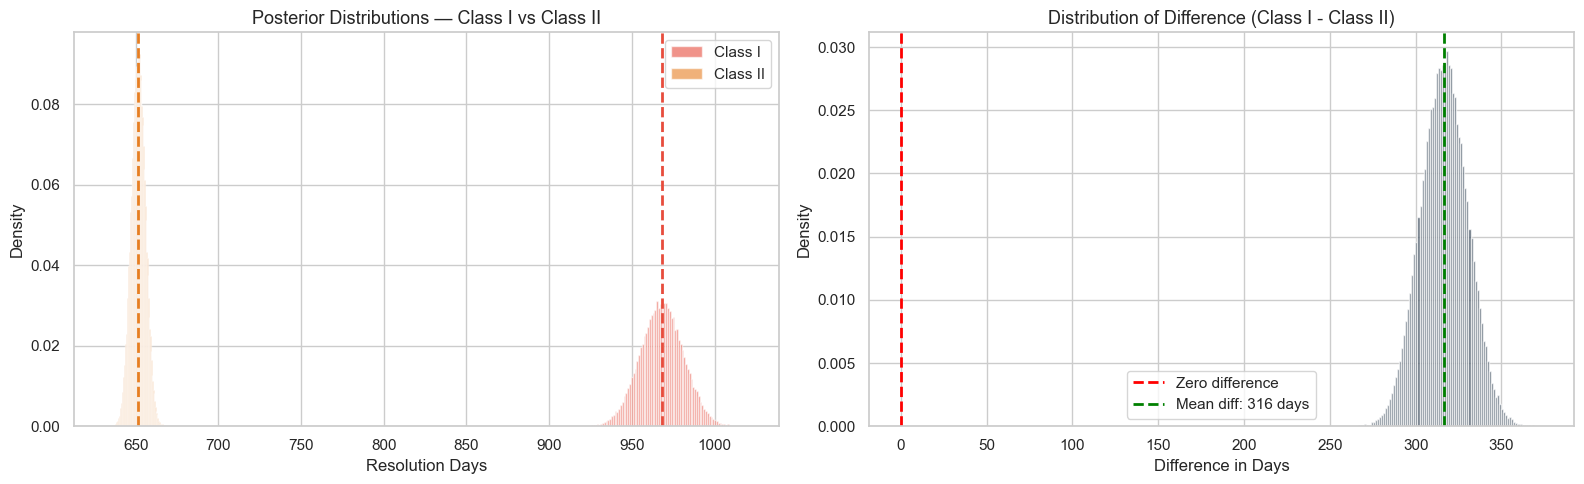

In [12]:
#Visualize The Posteriors
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot posterior distributions
axes[0].hist(posterior_a, bins=100, alpha=0.6, 
             color='#e74c3c', label='Class I', density=True)
axes[0].hist(posterior_b, bins=100, alpha=0.6, 
             color='#e67e22', label='Class II', density=True)
axes[0].axvline(group_a.mean(), color='#e74c3c', 
                linestyle='--', linewidth=2)
axes[0].axvline(group_b.mean(), color='#e67e22', 
                linestyle='--', linewidth=2)
axes[0].set_title('Posterior Distributions — Class I vs Class II', fontsize=13)
axes[0].set_xlabel('Resolution Days')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot difference distribution
diff_samples = posterior_a - posterior_b
axes[1].hist(diff_samples, bins=100, 
             color='#2c3e50', alpha=0.7, density=True)
axes[1].axvline(0, color='red', linestyle='--', 
                linewidth=2, label='Zero difference')
axes[1].axvline(diff_samples.mean(), color='green', 
                linestyle='--', linewidth=2, 
                label=f'Mean diff: {diff_samples.mean():.0f} days')
axes[1].set_title('Distribution of Difference (Class I - Class II)', fontsize=13)
axes[1].set_xlabel('Difference in Days')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/06_bayesian_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 95% Credible Interval for the difference
ci_lower = np.percentile(diff_samples, 2.5)
ci_upper = np.percentile(diff_samples, 97.5)

print("         95% CREDIBLE INTERVAL")
print(f"Mean Difference : {diff_samples.mean():.0f} days")
print(f"Lower Bound     : {ci_lower:.0f} days")
print(f"Upper Bound     : {ci_upper:.0f} days")
print(f"There is a 95% probability the true difference")
print(f"is between {ci_lower:.0f} and {ci_upper:.0f} days")

         95% CREDIBLE INTERVAL
Mean Difference : 316 days
Lower Bound     : 289 days
Upper Bound     : 343 days
There is a 95% probability the true difference
is between 289 and 343 days


In [16]:
# Final Bayesian Summary Table
summary_bayes = pd.DataFrame({
    'Metric': [
        'Group A (Class I) Mean',
        'Group B (Class II) Mean',
        'Mean Difference',
        'P(Class I slower than Class II)',
        'Credible Interval Lower (95%)',
        'Credible Interval Upper (95%)',
        'Monte Carlo Samples',
        'Result'
    ],
    'Value': [
        f'{group_a.mean():.0f} days',
        f'{group_b.mean():.0f} days',
        f'{diff_samples.mean():.0f} days',
        f'{prob_a_slower*100:.4f}%',
        f'{ci_lower:.0f} days',
        f'{ci_upper:.0f} days',
        f'{n_samples:,}',
        ' Class I Significantly Slower'
    ]
})

summary_bayes.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13px'
}).hide(axis='index')

Metric,Value
Group A (Class I) Mean,968 days
Group B (Class II) Mean,651 days
Mean Difference,316 days
P(Class I slower than Class II),100.0000%
Credible Interval Lower (95%),289 days
Credible Interval Upper (95%),343 days
Monte Carlo Samples,"100,000"
Result,Class I Significantly Slower
